**SCENARIOS**

SCENARIO 1

**BASE SETUP**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")

# Set timestamp
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")


cols = [
    "DE_load_actual_entsoe_transparency",
    "FR_load_actual_entsoe_transparency",
    "BE_load_actual_entsoe_transparency",
    "DE_wind_generation_actual",
    "DE_solar_generation_actual",
    "FR_solar_generation_actual",
    "BE_solar_generation_actual"
]

df_model = df[cols].copy().dropna()

# Build base demand and generation
df_model["total_demand"] = (
    df_model["DE_load_actual_entsoe_transparency"] +
    df_model["FR_load_actual_entsoe_transparency"] +
    df_model["BE_load_actual_entsoe_transparency"]
)

df_model["total_generation"] = (
    df_model["DE_wind_generation_actual"] +
    df_model["DE_solar_generation_actual"] +
    df_model["FR_solar_generation_actual"] +
    df_model["BE_solar_generation_actual"]
)

df_model["other_generation"] = 50000  # adjust if needed
df_model["total_generation"] = df_model["total_generation"] + df_model["other_generation"]

# Base grid balance
df_model["grid_balance"] = df_model["total_generation"] - df_model["total_demand"]

print(df_model.head())

                           DE_load_actual_entsoe_transparency  \
utc_timestamp                                                   
2015-01-01 08:00:00+00:00                             42963.0   
2015-01-01 09:00:00+00:00                             45088.0   
2015-01-01 10:00:00+00:00                             47013.0   
2015-01-01 11:00:00+00:00                             48159.0   
2015-01-01 12:00:00+00:00                             47164.0   

                           FR_load_actual_entsoe_transparency  \
utc_timestamp                                                   
2015-01-01 08:00:00+00:00                             64277.0   
2015-01-01 09:00:00+00:00                             65100.0   
2015-01-01 10:00:00+00:00                             65875.0   
2015-01-01 11:00:00+00:00                             67460.0   
2015-01-01 12:00:00+00:00                             65706.0   

                           BE_load_actual_entsoe_transparency  \
utc_timestamp          

**SCENARIO 1**

DEMAND SURGE

Heatwave → more air conditioning → demand ↑

In [3]:
df_scenario1 = df_model.copy()

# Increase total demand by 10%
df_scenario1["total_demand"] = df_scenario1["total_demand"] * 1.10

# Recalculate balance
df_scenario1["grid_balance"] = df_scenario1["total_generation"] - df_scenario1["total_demand"]

**SCENARIO 2**

No wind day → wind turbines produce less

In [12]:
df_scenario2 = df_model.copy()

# Reduce German wind generation by 30%
df_scenario2["DE_wind_generation_actual"] = df_scenario2["DE_wind_generation_actual"] * 0.70

# Recalculate generation
df_scenario2["total_generation"] = (
    df_scenario2["DE_wind_generation_actual"] +
    df_scenario2["DE_solar_generation_actual"] +
    df_scenario2["FR_solar_generation_actual"] +
    df_scenario2["BE_solar_generation_actual"] +
    df_scenario2["other_generation"]
)

# Recalculate balance
df_scenario2["grid_balance"] = df_scenario2["total_generation"] - df_scenario2["total_demand"]

**SCENARIO 3**

More solar panels → higher production

In [5]:
df_scenario3 = df_model.copy()

# Increase German solar generation by 20%
df_scenario3["DE_solar_generation_actual"] = df_scenario3["DE_solar_generation_actual"] * 1.20

# Recalculate generation
df_scenario3["total_generation"] = (
    df_scenario3["DE_wind_generation_actual"] +
    df_scenario3["DE_solar_generation_actual"] +
    df_scenario3["FR_solar_generation_actual"] +
    df_scenario3["BE_solar_generation_actual"] +
    df_scenario3["other_generation"]
)

# Recalculate balance
df_scenario3["grid_balance"] = df_scenario3["total_generation"] - df_scenario3["total_demand"]

Text(0.5, 0, 'Time')

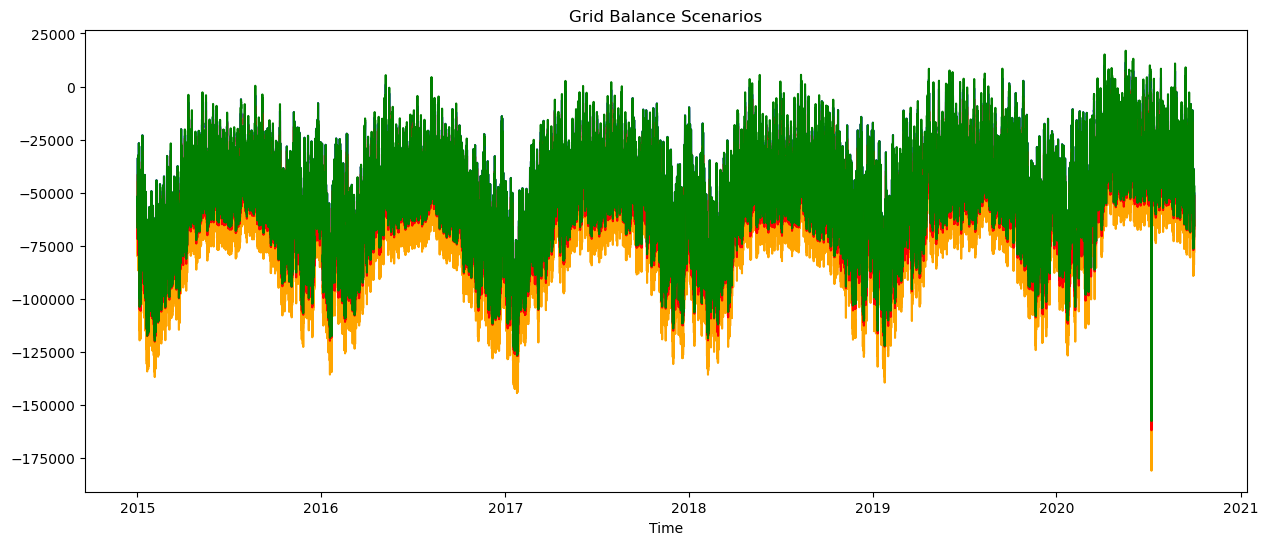

In [11]:
import matplotlib.dates as mdates
plt.figure(figsize=(15, 6))
plt.plot(df_model.index, df_model["grid_balance"], label="Base", color="blue")
plt.plot(df_scenario1.index, df_scenario1["grid_balance"], label="Demand +10%", color="orange")
plt.plot(df_scenario2.index, df_scenario2["grid_balance"], label="Wind -30%", color="red")
plt.plot(df_scenario3.index, df_scenario3["grid_balance"], label="Solar +20%", color="green")
plt.title("Grid Balance Scenarios")
plt.xlabel("Time")  

In [6]:
def shortage_rate(df_in):
    return (df_in["grid_balance"] < 0).mean() * 100

print("Base shortage rate:      ", round(shortage_rate(df_model), 2), "%")
print("Demand surge shortage:   ", round(shortage_rate(df_scenario1), 2), "%")
print("Wind drop shortage:      ", round(shortage_rate(df_scenario2), 2), "%")
print("Solar increase shortage: ", round(shortage_rate(df_scenario3), 2), "%")

Base shortage rate:       99.77 %
Demand surge shortage:    99.99 %
Wind drop shortage:       99.96 %
Solar increase shortage:  99.48 %


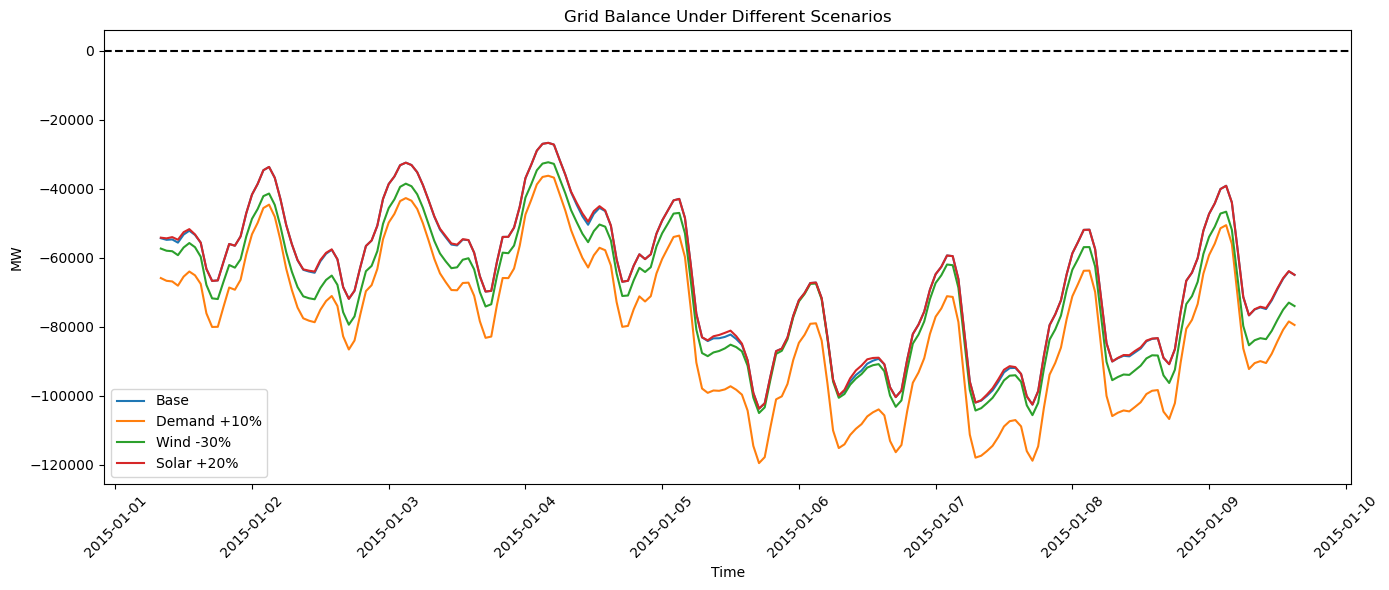

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(df_model.index[:200], df_model["grid_balance"].iloc[:200], label="Base")
plt.plot(df_scenario1.index[:200], df_scenario1["grid_balance"].iloc[:200], label="Demand +10%")
plt.plot(df_scenario2.index[:200], df_scenario2["grid_balance"].iloc[:200], label="Wind -30%")
plt.plot(df_scenario3.index[:200], df_scenario3["grid_balance"].iloc[:200], label="Solar +20%")

plt.axhline(0, color="black", linestyle="--")
plt.title("Grid Balance Under Different Scenarios")
plt.ylabel("MW")
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
scenario_results = pd.DataFrame({
    "Scenario": ["Base", "Demand +10%", "Wind -30%", "Solar +20%"],
    "Shortage Rate (%)": [
        shortage_rate(df_model),
        shortage_rate(df_scenario1),
        shortage_rate(df_scenario2),
        shortage_rate(df_scenario3)
    ],
    "Average Balance (MW)": [
        df_model["grid_balance"].mean(),
        df_scenario1["grid_balance"].mean(),
        df_scenario2["grid_balance"].mean(),
        df_scenario3["grid_balance"].mean()
    ]
})

print(scenario_results)

      Scenario  Shortage Rate (%)  Average Balance (MW)
0         Base          99.765155         -50907.454422
1  Demand +10%          99.990049         -62760.756950
2    Wind -30%          99.962186         -54373.675713
3   Solar +20%          99.484536         -49993.937629


Increasing solar capacity improves grid stability during daylight hours,
but does not fully solve evening demand peaks.


-Demand +10%: stress on the grid from heatwave, cold wave, or consumption spike

-Wind -30%: renewable supply shock

-Solar +20%: policy / infrastructure improvement scenario

-demand surge worsens the balance

-wind drop worsens the balance a lot

-solar increase improves daytime balance, but not all hours